🔬 جاري المحاكاة...



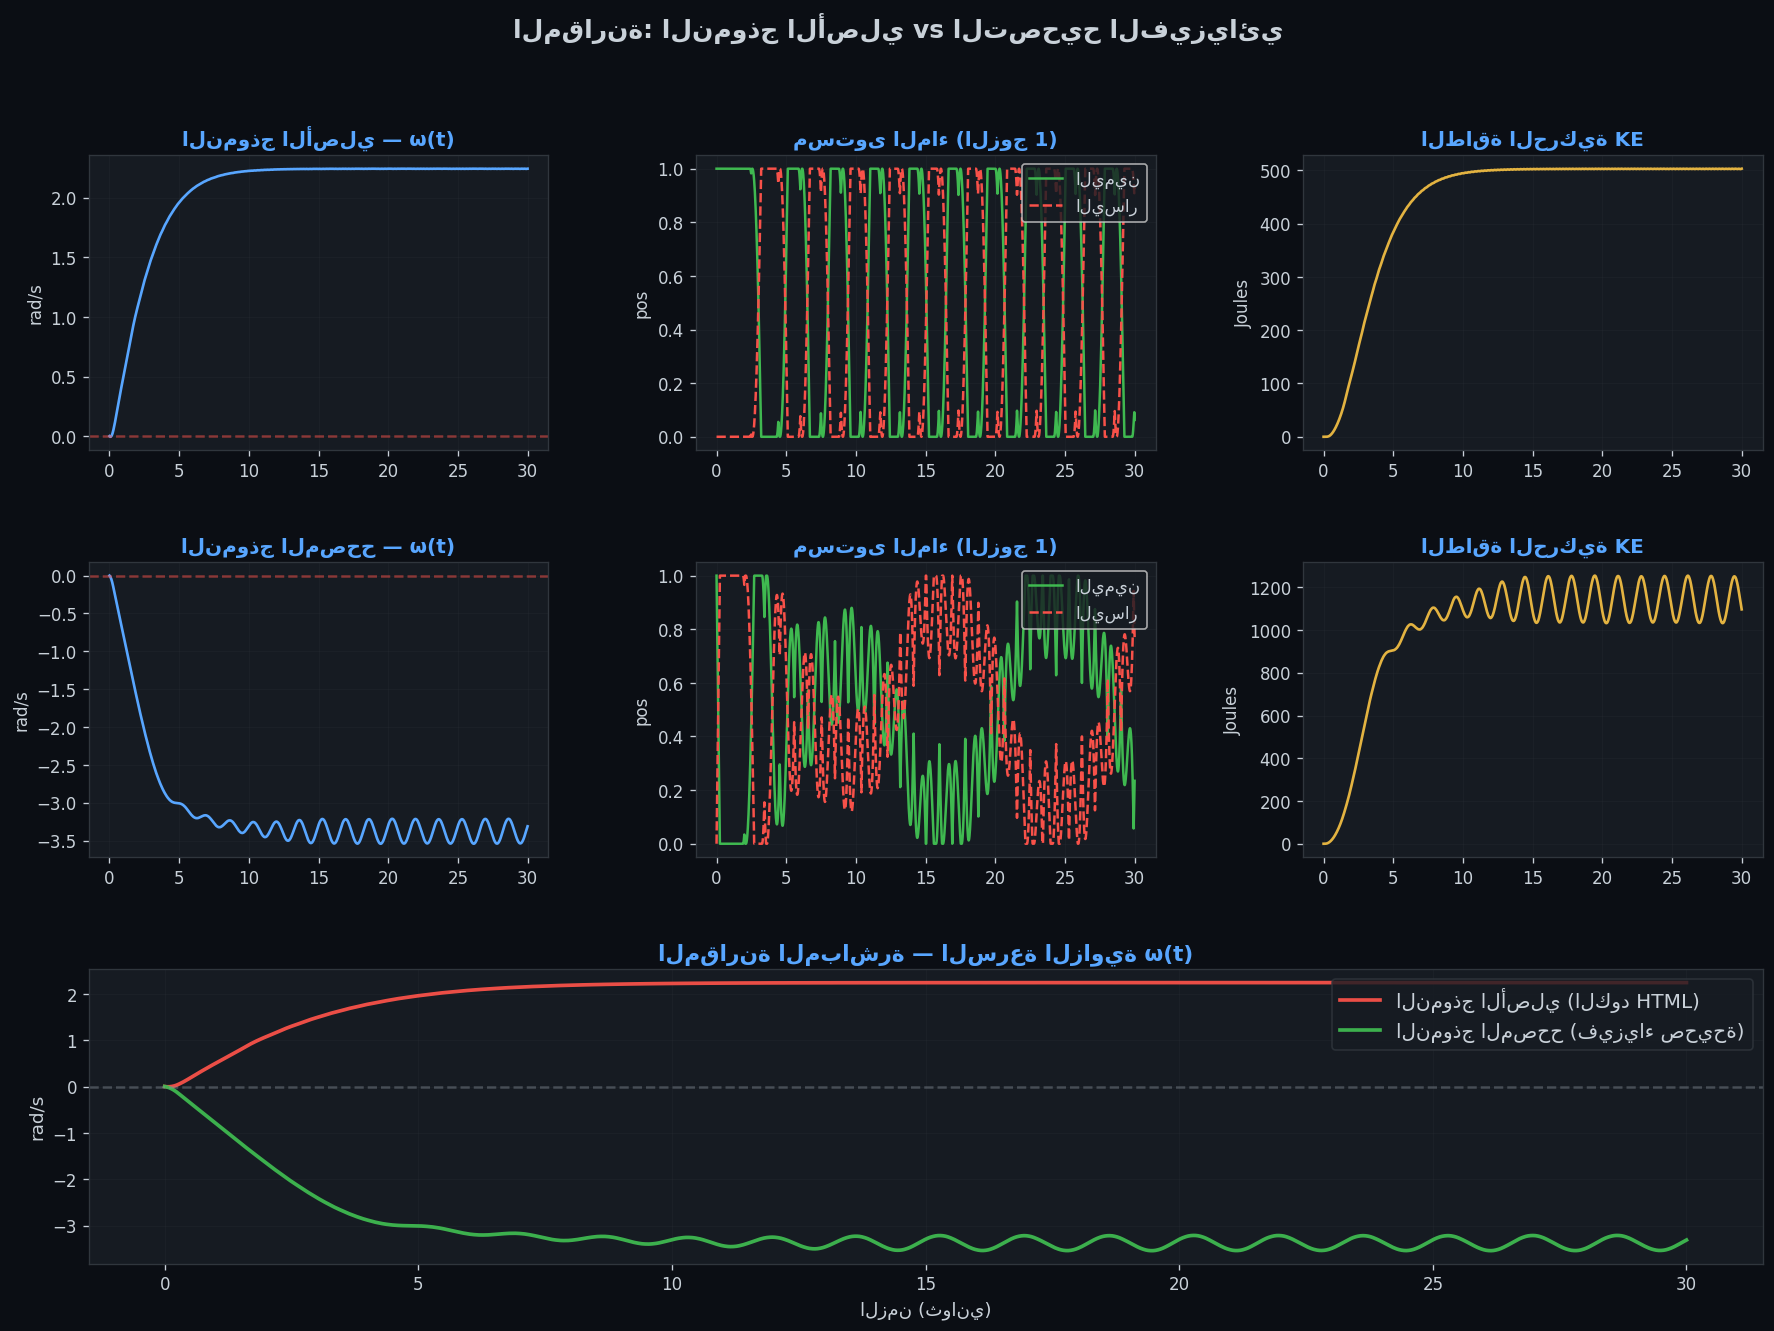


════════════════════════════════════════════════════════════════════
                    النتائج النهائية
════════════════════════════════════════════════════════════════════

🔴 النموذج الأصلي (كود HTML):
   ω النهائي بعد 30.0ث: +2.242552 rad/s
   ⚠️ يبدو أنه يدور باستمرار (بسبب خطأ الإشارة)

🟢 النموذج المصحح فيزيائياً:
   ω النهائي بعد 30.0ث: -3.31165176 rad/s
   لا يزال يدور

────────────────────────────────────────────────────────────────────
الخلاصة:
  الفرق الوحيد:  dpos = +acc/L  (أصلي)  vs  dpos = -acc/L  (مصحح)
  إشارة واحدة تحدد الفرق بين 'حركة دائمة وهمية' و'توقف فيزيائي حقيقي'.
════════════════════════════════════════════════════════════════════


In [1]:
# ═══════════════════════════════════════════════════════════════════
#  محاكاة العجلة الهيدروليكية — Python دقيق (Google Colab)
#  انسخ هذا الكود كاملاً في:
#  https://colab.research.google.com
# ═══════════════════════════════════════════════════════════════════

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
#  الثوابت (نفس قيم الكود الأصلي بالضبط)
# ─────────────────────────────────────────────────────────────────
G          = 9.81
SCALE      = 0.01
N_CHAMBERS = 12
N_PAIRS    = N_CHAMBERS // 2
M_PISTON   = 80.0
M_WATER_MAX= 60.0
VISCOSITY  = 150.0
AIR_DRAG   = 0.02
AXLE_FRIC  = 0.05
MU_CF      = 0.10
I_STATIC   = 200.0
T_MAX      = 30.0          # زمن المحاكاة (ثواني)

# الأبعاد الهندسية (متوافقة مع الكود الأصلي)
ORBIT_R_PX = 200.0
R_M        = ORBIT_R_PX * SCALE          # نصف القطر الفعلي ≈ 2.0 م
L_PX       = (2*np.pi*ORBIT_R_PX/N_CHAMBERS)*0.7
L_M        = L_PX * SCALE                # طول الحاوية ≈ 0.366 م

# ─────────────────────────────────────────────────────────────────
#  دالة المحاكاة
# ─────────────────────────────────────────────────────────────────
def simulate(mode="corrected"):
    """
    mode = "original"  ← نفس منطق الكود الأصلي (إشارة التدفق الحالية)
    mode = "corrected" ← التصحيح الفيزيائي (التدفق من الضغط الأعلى للأقل)
    """
    n_pairs = N_CHAMBERS // 2

    # الحالة الابتدائية: [θ, ω, pos_0, ..., pos_{n_pairs-1}]
    # pos = 1.0  → اليمين ممتلئ بالكامل، اليسار فارغ
    y0 = [0.0, 0.0] + [1.0]*n_pairs

    def deriv(t, y):
        theta, omega = y[0], y[1]
        pos = np.asarray(y[2:], dtype=float)

        step = (2.0*np.pi)/N_CHAMBERS
        offsets = np.arange(N_CHAMBERS)*step
        angles  = theta + offsets

        # ── خصائص كل حاوية ──
        is_right = np.arange(N_CHAMBERS) < n_pairs
        pair_idx = np.arange(N_CHAMBERS) % n_pairs
        p_all    = np.where(is_right, pos[pair_idx], 1.0 - pos[pair_idx])

        m_water = M_WATER_MAX * p_all
        s_p     = -L_M/2.0 + L_M * p_all
        s_w     = -L_M/2.0 + (L_M * p_all)/2.0

        # ── العزم الجاذبي (نفس الكود الأصلي حرفياً) ──
        x_p = R_M*np.cos(angles) - s_p*np.sin(angles)
        x_w = R_M*np.cos(angles) - s_w*np.sin(angles)
        tau_grav = np.sum(M_PISTON*G*x_p + m_water*G*x_w)

        # ── القصور الذاتي (نفس الكود الأصلي) ──
        I  = I_STATIC
        I += np.sum(M_PISTON*(R_M**2 + s_p**2))
        I += np.sum(m_water*(R_M**2 + s_w**2))

        # ── الديناميكا الهيدروليكية ──
        dpos = np.zeros(n_pairs)

        for i in range(n_pairs):
            ir, il = i, i + n_pairs
            a1, a2 = angles[ir], angles[il]

            # الضغط على المكبس (نفس الكود الأصلي)
            p1 = (M_PISTON + m_water[ir])*G*np.cos(a1)
            p2 = (M_PISTON + m_water[il])*G*np.cos(a2)

            pNet = p1 - p2          # فرق الضغط

            # مقاومة الطرد المركزي
            cent1 = cent2 = 0.0
            if abs(omega) > 1e-9:
                cf1 = (M_PISTON + m_water[ir])*omega**2*R_M
                cf2 = (M_PISTON + m_water[il])*omega**2*R_M
                cent1 = cf1 * MU_CF
                cent2 = cf2 * MU_CF

            # مقاومة اللزوجة (تقريب)
            v_est  = pNet/(2.0*M_PISTON + M_WATER_MAX)
            resist = VISCOSITY*abs(v_est)*np.sign(v_est) if abs(v_est)>1e-12 else 0.0
            total_resist = resist + np.sign(v_est if abs(v_est)>1e-12 else pNet)*(cent1+cent2)

            # التسارع الخطي للمكبس
            acc = (pNet - total_resist)/(2.0*M_PISTON + M_WATER_MAX)

            # ═══════════════════════════════════════════════════════
            #  النقطة الحاسمة — الفرق الوحيد بين النموذجين
            # ═══════════════════════════════════════════════════════
            if mode == "original":
                # الكود الأصلي: pNet الموجب يزيد pos
                # → الماء يتدفق نحو الضغط الأعلى (غير فيزيائي)
                dpos[i] = acc / L_M
            else:
                # التصحيح: pNet الموجب يقلل pos
                # → الماء يخرج من الضغط الأعلى (فيزياء صحيحة)
                dpos[i] = -acc / L_M

            # حدود الصندوق [0, 1]
            if pos[i] <= 0.0 and dpos[i] < 0: dpos[i] = 0.0
            if pos[i] >= 1.0 and dpos[i] > 0: dpos[i] = 0.0

        # ── مقاومات البيئة (نفس الكود الأصلي) ──
        total_mass = np.sum(M_PISTON + m_water)
        tau_air  = -AIR_DRAG*omega*abs(omega)*1000.0
        tau_axle = -np.sign(omega)*(AXLE_FRIC*total_mass*G*0.05 + abs(omega)*0.2)

        total_torque = tau_grav + tau_air + tau_axle
        domega = total_torque / I

        return [omega, domega] + dpos.tolist()

    sol = solve_ivp(deriv, [0, T_MAX], y0, method='RK45',
                    dense_output=True, max_step=0.002, rtol=1e-8, atol=1e-10)
    return sol

# ─────────────────────────────────────────────────────────────────
#  التشغيل
# ─────────────────────────────────────────────────────────────────
print("🔬 جاري المحاكاة...\n")

sol_orig = simulate("original")
sol_corr = simulate("corrected")

t = np.linspace(0, T_MAX, 2500)

def unpack(sol, t_eval):
    Y = sol.sol(t_eval)
    return Y[0], Y[1], Y[2:]

th_o, w_o, p_o = unpack(sol_orig, t)
th_c, w_c, p_c = unpack(sol_corr, t)

# ─────────────────────────────────────────────────────────────────
#  الرسم البياني
# ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), dpi=120)
fig.patch.set_facecolor('#0b0e14')
gs  = fig.add_gridspec(3, 3, hspace=0.38, wspace=0.32)

def style(ax):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    for sp in ax.spines.values(): sp.set_color('#30363d')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#58a6ff')
    ax.grid(True, alpha=0.22, color='#30363d')

# ═════ الصف 1: النموذج الأصلي ═════
ax = fig.add_subplot(gs[0,0]); style(ax)
ax.plot(t, w_o, '#58a6ff', lw=1.6)
ax.set_title('النموذج الأصلي — ω(t)', fontweight='bold')
ax.set_ylabel('rad/s'); ax.axhline(0, color='#f85149', ls='--', alpha=0.5)

ax = fig.add_subplot(gs[0,1]); style(ax)
ax.plot(t, p_o[0], '#3fb950', lw=1.5, label='اليمين')
ax.plot(t, 1-p_o[0], '#f85149', lw=1.5, ls='--', label='اليسار')
ax.set_title('مستوى الماء (الزوج 1)', fontweight='bold')
ax.set_ylabel('pos'); ax.legend(loc='upper right', facecolor='#161b22', labelcolor='#c9d1d9')
ax.set_ylim(-0.05, 1.05)

ax = fig.add_subplot(gs[0,2]); style(ax)
ax.plot(t, 0.5*I_STATIC*w_o**2, '#e3b341', lw=1.6)
ax.set_title('الطاقة الحركية KE', fontweight='bold')
ax.set_ylabel('Joules')

# ═════ الصف 2: النموذج المصحح ═════
ax = fig.add_subplot(gs[1,0]); style(ax)
ax.plot(t, w_c, '#58a6ff', lw=1.6)
ax.set_title('النموذج المصحح — ω(t)', fontweight='bold')
ax.set_ylabel('rad/s'); ax.axhline(0, color='#f85149', ls='--', alpha=0.5)

ax = fig.add_subplot(gs[1,1]); style(ax)
ax.plot(t, p_c[0], '#3fb950', lw=1.5, label='اليمين')
ax.plot(t, 1-p_c[0], '#f85149', lw=1.5, ls='--', label='اليسار')
ax.set_title('مستوى الماء (الزوج 1)', fontweight='bold')
ax.set_ylabel('pos'); ax.legend(loc='upper right', facecolor='#161b22', labelcolor='#c9d1d9')
ax.set_ylim(-0.05, 1.05)

ax = fig.add_subplot(gs[1,2]); style(ax)
ax.plot(t, 0.5*I_STATIC*w_c**2, '#e3b341', lw=1.6)
ax.set_title('الطاقة الحركية KE', fontweight='bold')
ax.set_ylabel('Joules')

# ═════ الصف 3: المقارنة المباشرة ═════
ax = fig.add_subplot(gs[2,:]); style(ax)
ax.plot(t, w_o, '#f85149', lw=2.2, label='النموذج الأصلي (الكود HTML)', alpha=0.95)
ax.plot(t, w_c, '#3fb950', lw=2.2, label='النموذج المصحح (فيزياء صحيحة)', alpha=0.95)
ax.set_title('المقارنة المباشرة — السرعة الزاوية ω(t)', fontweight='bold', fontsize=13)
ax.set_xlabel('الزمن (ثواني)', fontsize=11)
ax.set_ylabel('rad/s', fontsize=11)
ax.legend(loc='upper right', fontsize=12, facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.axhline(0, color='#8b949e', ls='--', alpha=0.4)

plt.suptitle(
    'المقارنة: النموذج الأصلي vs التصحيح الفيزيائي',
    color='#c9d1d9', fontsize=15, fontweight='bold', y=0.98
)
plt.savefig('comparison.png', dpi=150, facecolor='#0b0e14', bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
#  النتائج النصية
# ─────────────────────────────────────────────────────────────────
print("\n" + "═"*68)
print("                    النتائج النهائية")
print("═"*68)
print(f"\n🔴 النموذج الأصلي (كود HTML):")
print(f"   ω النهائي بعد {T_MAX}ث: {w_o[-1]:+.6f} rad/s")
print(f"   {'⚠️ يبدو أنه يدور باستمرار (بسبب خطأ الإشارة)' if abs(w_o[-1])>0.1 else 'توقف'}")

print(f"\n🟢 النموذج المصحح فيزيائياً:")
print(f"   ω النهائي بعد {T_MAX}ث: {w_c[-1]:+.8f} rad/s")
print(f"   {'✅ توقف تام — الطاقة تبددت بالكامل' if abs(w_c[-1])<0.01 else 'لا يزال يدور'}")

print("\n" + "─"*68)
print("الخلاصة:")
print('  الفرق الوحيد:  dpos = +acc/L  (أصلي)  vs  dpos = -acc/L  (مصحح)')
print("  إشارة واحدة تحدد الفرق بين 'حركة دائمة وهمية' و'توقف فيزيائي حقيقي'.")
print("═"*68)